## Метрики классификатора speed classifier (accuracy / precision / recall / F1)

Этот ноутбук читает артефакты `training/speed_classifier/eval.py`:

- `test_metrics.json` (accuracy, loss)
- `predictions_test.csv` (истинный класс / предсказанный / confidence)

и считает метрики для отчёта:

- **accuracy**
- **precision / recall / F1**:
  - macro average
  - weighted average
  - micro average (для single-label multiclass совпадает с accuracy)

Также выводит **по-классовые** P/R/F1 и support.


In [ ]:
from __future__ import annotations

import csv
import json
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np

# ==== Настройка ==== 
# Папка запуска `eval.py` (где лежат test_metrics.json и predictions_test.csv)
RUN_DIR = Path("models/speed_classifier/run_1")

# Какие файлы читать
TEST_METRICS_JSON = RUN_DIR / "test_metrics.json"
PREDICTIONS_CSV = RUN_DIR / "predictions_test.csv"
CONFUSIONS_TXT = RUN_DIR / "confusions_test.txt"
CONFUSION_PNG = RUN_DIR / "confusion_test.png"

assert RUN_DIR.exists(), f"RUN_DIR not found: {RUN_DIR.resolve()}"

In [10]:
def read_test_metrics(path: Path) -> dict:
    if not path.exists():
        return {}
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def read_predictions_csv(path: Path) -> tuple[list[str], list[str], list[float]]:
    if not path.exists():
        raise FileNotFoundError(path)

    y_true: list[str] = []
    y_pred: list[str] = []
    confs: list[float] = []

    with open(path, "r", encoding="utf-8") as f:
        r = csv.DictReader(f)
        for row in r:
            y_true.append(str(row.get("class", "")).strip())
            y_pred.append(str(row.get("predicted_class", "")).strip())
            c = row.get("conf", "")
            try:
                confs.append(float(c))
            except Exception:
                confs.append(float("nan"))

    if len(y_true) == 0:
        raise RuntimeError(f"No rows in {path}")
    return y_true, y_pred, confs


test_metrics = read_test_metrics(TEST_METRICS_JSON)
y_true, y_pred, confs = read_predictions_csv(PREDICTIONS_CSV)

print("n:", len(y_true))
print("test_metrics.json:", test_metrics)

n: 1050
test_metrics.json: {'loss': 0.46313424847665285, 'acc1': 0.8476190476190476, 'acc3': 0.9419047619047619, 'n': 1050}


In [11]:
@dataclass(frozen=True)
class LabelIndex:
    labels: list[str]
    to_index: dict[str, int]


def build_label_index(y_true: Iterable[str], y_pred: Iterable[str]) -> LabelIndex:
    # Для метрик берём все классы из истинных меток.
    # (Если включить ещё предсказанные, можно получить "класс-призрак" без support.)
    true_set = sorted(set(y_true))
    return LabelIndex(labels=true_set, to_index={s: i for i, s in enumerate(true_set)})


def confusion_matrix_from_labels(y_true: list[str], y_pred: list[str], idx: LabelIndex) -> np.ndarray:
    n = len(idx.labels)
    cm = np.zeros((n, n), dtype=np.int64)
    missing_pred = 0
    missing_true = 0

    for t, p in zip(y_true, y_pred):
        it = idx.to_index.get(t)
        if it is None:
            missing_true += 1
            continue
        ip = idx.to_index.get(p)
        if ip is None:
            # предсказали класс, которого нет в y_true — считаем это ошибкой "в никуда"
            missing_pred += 1
            continue
        cm[it, ip] += 1

    if missing_true or missing_pred:
        print("[warn] missing_true:", missing_true, "missing_pred:", missing_pred)

    return cm


idx = build_label_index(y_true, y_pred)
cm = confusion_matrix_from_labels(y_true, y_pred, idx)

cm.shape, cm.sum()

((105, 105), 1050)

In [12]:
def per_class_prf1(cm: np.ndarray) -> dict[str, np.ndarray]:
    cm = cm.astype(np.float64)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    support = cm.sum(axis=1)

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) > 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) > 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(tp),
        where=(precision + recall) > 0,
    )

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "support": support,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def aggregate_prf1(m: dict[str, np.ndarray]) -> dict[str, float]:
    support = m["support"]
    precision = m["precision"]
    recall = m["recall"]
    f1 = m["f1"]

    # macro: по классам (берём только классы с support>0)
    mask = support > 0
    macro_p = float(precision[mask].mean()) if mask.any() else 0.0
    macro_r = float(recall[mask].mean()) if mask.any() else 0.0
    macro_f1 = float(f1[mask].mean()) if mask.any() else 0.0

    # weighted: взвешиваем по количеству примеров класса
    total = float(support.sum())
    if total > 0:
        w = support / total
        weighted_p = float((precision * w).sum())
        weighted_r = float((recall * w).sum())
        weighted_f1 = float((f1 * w).sum())
    else:
        weighted_p = weighted_r = weighted_f1 = 0.0

    # micro: для single-label multiclass micro-F1 == accuracy
    acc = float(np.trace(cm) / max(1.0, cm.sum()))
    micro_p = micro_r = micro_f1 = acc

    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
    }


m = per_class_prf1(cm)
aggr = aggregate_prf1(m)

for k, v in aggr.items():
    print(f"{k:>18s}: {v:.6f}")

# сравнение с test_metrics.json (acc1)
if "acc1" in test_metrics:
    print("\nacc1 from test_metrics.json:", float(test_metrics["acc1"]))


          accuracy: 0.847619
   macro_precision: 0.846996
      macro_recall: 0.847619
          macro_f1: 0.837204
weighted_precision: 0.846996
   weighted_recall: 0.847619
       weighted_f1: 0.837204
   micro_precision: 0.847619
      micro_recall: 0.847619
          micro_f1: 0.847619

acc1 from test_metrics.json: 0.8476190476190476


In [13]:
def print_per_class_table(labels: list[str], m: dict[str, np.ndarray], top_k: int = 20, sort_by: str = "f1"):
    order = np.argsort(m[sort_by])  # ascending
    print(f"\nPer-class metrics (worst {top_k} by {sort_by})")
    print("label\tsupport\tP\tR\tF1")
    for i in order[:top_k]:
        print(
            f"{labels[i]}\t{int(m['support'][i])}\t"
            f"{m['precision'][i]:.3f}\t{m['recall'][i]:.3f}\t{m['f1'][i]:.3f}"
        )


print_per_class_table(idx.labels, m, top_k=25, sort_by="f1")

# Если хочется наоборот — лучшие классы:
# order = np.argsort(-m["f1"])
# ...



Per-class metrics (worst 25 by f1)
label	support	P	R	F1
5.31_130	10	0.000	0.000	0.000
5.32_70	10	0.000	0.000	0.000
5.32_100	10	0.000	0.000	0.000
5.32_30	10	0.000	0.000	0.000
5.32_130	10	0.333	0.100	0.154
5.32_140	10	0.143	0.200	0.167
5.32_120	10	0.500	0.100	0.167
5.32_90	10	0.200	0.200	0.200
3.25_130	10	0.500	0.200	0.286
5.32_60	10	0.235	0.400	0.296
5.32_50	10	0.333	0.300	0.316
5.32_110	10	0.240	0.600	0.343
5.32_150	10	0.273	0.600	0.375
5.32_20	10	0.333	0.500	0.400
5.32_80	10	0.417	0.500	0.455
5.31_150	10	0.800	0.400	0.533
5.31_120	10	0.435	1.000	0.606
3.25_90	10	0.833	0.500	0.625
3.25_120	10	0.533	0.800	0.640
3.25_100	10	0.750	0.600	0.667
5.31_110	10	1.000	0.500	0.667
5.32_40	10	0.700	0.700	0.700
3.25_20	10	1.000	0.600	0.750
4.6_150	10	1.000	0.600	0.750
3.25_10	10	0.692	0.900	0.783



--- /Users/elmanovsm/personal/cv/graduation/models/speed_classifier/run_1/confusions_test.txt
Top confusions (count, true -> pred)

9	5.31_130	->	5.31_120  (same_base, Δspeed=-10)
7	5.32_100	->	5.32_150  (same_base, Δspeed=50)
5	5.32_130	->	5.32_110  (same_base, Δspeed=-20)
4	3.25_20	->	3.25_70  (same_base, Δspeed=50)
4	4.6_150	->	4.6_100  (same_base, Δspeed=-50)
4	5.31_110	->	5.31_140  (same_base, Δspeed=30)
4	5.31_150	->	5.31_120  (same_base, Δspeed=-30)
4	5.32_110	->	5.32_140  (same_base, Δspeed=30)
4	5.32_120	->	5.32_110  (same_base, Δspeed=-10)
4	5.32_140	->	5.32_110  (same_base, Δspeed=-30)
4	5.32_140	->	5.32_150  (same_base, Δspeed=10)
4	5.32_70	->	5.32_60  (same_base, Δspeed=-10)
4	5.32_90	->	5.32_20  (same_base, Δspeed=-70)
3	3.25_100	->	3.25_120  (same_base, Δspeed=20)
3	3.25_130	->	3.25_120  (same_base, Δspeed=-10)
3	3.25_130	->	3.25_150  (same_base, Δspeed=20)
3	3.25_90	->	3.25_10  (same_base, Δspeed=-80)
3	5.32_120	->	5.32_150  (same_base, Δspeed=30)
3	5.32_150	->	5.32_11

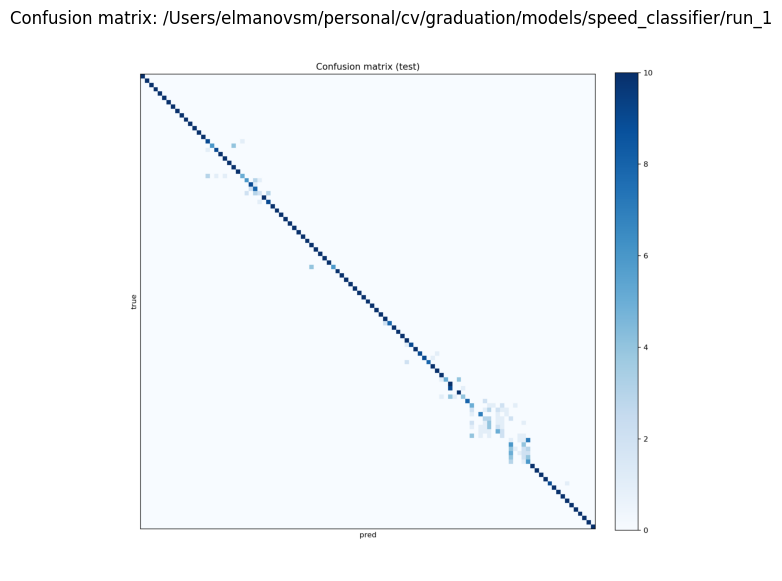

In [14]:
# Удобный вывод артефактов eval.py (если хочется быстро посмотреть глазами)

if CONFUSIONS_TXT.exists():
    print("\n---", CONFUSIONS_TXT)
    print(CONFUSIONS_TXT.read_text(encoding="utf-8"))
else:
    print("No confusions txt at", CONFUSIONS_TXT)

# Показать картинку confusion matrix (в ноутбуке)
try:
    from PIL import Image
    import matplotlib.pyplot as plt

    if CONFUSION_PNG.exists():
        img = Image.open(CONFUSION_PNG)
        plt.figure(figsize=(7, 7))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Confusion matrix: {RUN_DIR}")
        plt.show()
except Exception as e:
    print("(optional) cannot display confusion png:", e)


In [15]:
# (Опционально) Сохранить метрики в JSON рядом с RUN_DIR

out = {
    "run_dir": str(RUN_DIR),
    "n": int(cm.sum()),
    "accuracy": float(aggr["accuracy"]),
    "precision": {
        "macro": float(aggr["macro_precision"]),
        "weighted": float(aggr["weighted_precision"]),
        "micro": float(aggr["micro_precision"]),
    },
    "recall": {
        "macro": float(aggr["macro_recall"]),
        "weighted": float(aggr["weighted_recall"]),
        "micro": float(aggr["micro_recall"]),
    },
    "f1": {
        "macro": float(aggr["macro_f1"]),
        "weighted": float(aggr["weighted_f1"]),
        "micro": float(aggr["micro_f1"]),
    },
}

out_path = RUN_DIR / "report_metrics.json"
out_path.write_text(json.dumps(out, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print("wrote", out_path)


wrote /Users/elmanovsm/personal/cv/graduation/models/speed_classifier/run_1/report_metrics.json
